# For Will Cerny -- to figure out how to run SIMPLE/UGALI for detecting UFDs in Roman

Need to install `artpop` from this repo: https://github.com/AstroJacobLi/ArtPop

In [1]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
import artpop

In [2]:
Roman_zp_AB_Vega_parsec = {'F062': 0.1516780915703379,
    'F087': 0.5133462686585959,
    'F106': 0.6609068434593195,
    'F129': 1.1056961143945754,
    'F146': 1.1618106810147644,
    'F158': 1.3186852414129346,
    'F184': 1.558177315836199,
    'F213': 1.8362285584721012}

## Generate star and galaxy catalog

In [3]:
log_m_star = 5
gal_kwargs = {'age': (10**9.6) * u.yr,
              'feh': -2,
              'total_mass': 10**log_m_star,
              'r_eff': 0.2 * u.kpc,
              'distance': 3 * u.Mpc}

s = 2001 # size for generating the mock galaxy
pixel_scale = 0.11

dmod = 5 * np.log10(gal_kwargs['distance'].value) + 25
abs_mag_lim = 3
mag_lim = dmod + abs_mag_lim
print('mag lim', mag_lim)

mag lim 30.385606273598313


In [4]:
iso = artpop.Isochrone.from_parsec('PARSEC_v1.2S_Roman_vega_nTP20.dat',
                                   log_age=np.log10(gal_kwargs['age'].to(u.yr).value),
                                   MH=gal_kwargs['feh'])
iso.mag_table.rename_columns(iso.filters, 
                             [item.replace('mag', '') for item in iso.filters])

sp = artpop.SSP(iso, total_mass=gal_kwargs['total_mass'],
                distance=gal_kwargs['distance'],
                mag_limit=mag_lim, mag_limit_band='F158')

src = artpop.SersicSP(sp, n=0.8, theta=10 * u.deg, ellip=0.3,
                     r_eff=gal_kwargs['r_eff'], xy_dim=s, 
                      pixel_scale=pixel_scale)

print('# of stars', src.num_stars)
print('Sampled mass fraction:', src.sp.sampled_mass / src.sp.total_mass)
# convert Vega to AB
for filt in src.mags.colnames:
    src.mags[filt] += Roman_zp_AB_Vega_parsec[filt]

print('Total mag from stars', -2.5 * np.log10(np.sum(10**(-0.4 * src.mags['F158']))))
print('Total mag fron smooth', src.sp.mag_integrated_component('F158'))
print('SB of smooth', src.sp.mag_integrated_component('F158') + 2.5 * np.log10(2 * np.pi * src.smooth_model.r_eff.value**2 * 0.11**2))

        Use numpy.iterable() instead. [artpop.util]
        Use numpy.iterable() instead. [artpop.util]


# of stars 5555
Sampled mass fraction: 0.05731363635519106
Total mag from stars 19.49562954760397
Total mag fron smooth 19.90510161995975
SB of smooth 27.592220658241935


In [5]:
import utils

In [6]:
obs_ra, obs_dec = 11.8880580, -25.2888000 # NGC 253

ufd_cat = utils.gen_catalog_from_artpop(src, ra=obs_ra, dec=obs_dec)
# The flux is in maggies. To get mags, simply do: mag = -2.5 * np.log10(maggies)

To make a population of realistic background sources, I ran DOLPHOT on my simulated image. The catalog includes lots of background galaxies. I applied a very simple star-galaxy separation to the catalog (as `star_flag`). The `quality_flag` is used to remove poor PSF photometry results (due to low SNR and/or crowding).

In [34]:
exptime = 642
host = 'ngc253'
import pandas as pd
df = pd.read_csv('./ngc253_642s.phot.csv')
bkg_cat = Table.from_df(df)

Text(0, 0.5, 'Dec')

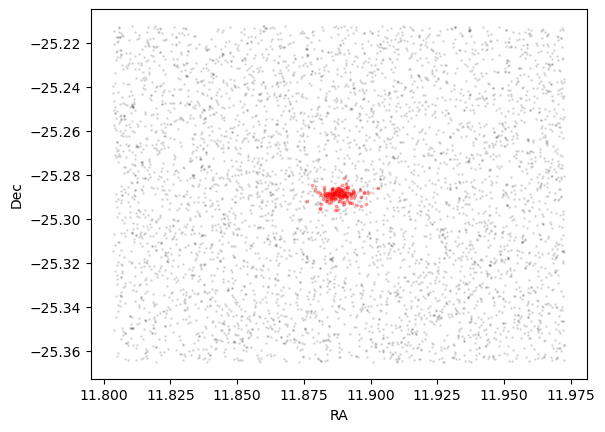

In [35]:
# Black dots = background point sources; red dots = UFD stars
flag = bkg_cat['star_flag']
plt.scatter(bkg_cat[flag]['ra'], bkg_cat[flag]['dec'], s=1, c='k', alpha=0.1)

flag = -2.5 * np.log10(ufd_cat['F158']) < 27
plt.scatter(ufd_cat['ra'][flag], ufd_cat['dec'][flag], s=3, c='r', ec='r', alpha=0.3)

plt.xlabel('RA')
plt.ylabel('Dec')

## Apply observational uncertainties and completeness

In [36]:
hlwas_completeness_dict = {'F106': [26.8276654500533, 0.4966708077077806], 
                           'F158': [26.472505389291722, 0.4872157948732412]} # HLWAS depth, sharp=0.03
hlwas_mag_uncertainty_dict = {'F106': [0.33745871, -9.60010621], 
                              'F158': [0.33819561, -9.55362927]} # HLWAS depth, sharp=0.03

In [44]:
rng = np.random.default_rng(123)
depth_HLWAS = 1

# Ultra-faint dwarf sources
ufd = utils.apply_obs_model_two_band(
    -2.5 * np.log10(ufd_cat["F106"]), 
    -2.5 * np.log10(ufd_cat["F158"]),
    bands=['F106', 'F158'],
    completeness_dict=hlwas_completeness_dict,
    mag_uncertainty_dict=hlwas_mag_uncertainty_dict,
    rng=rng,
    detection="both",     # since you care about colors
    depth_HLWAS=depth_HLWAS
)
ufd['RA'] = ufd_cat['ra']
ufd['DEC'] = ufd_cat['dec']
ufd['MC_SOURCE_ID'] = 1 # mark UFD stars
bkg = utils.setup_dolphot_cat(bkg_cat)
bkg['MC_SOURCE_ID'] == 0

array([ True,  True,  True, ...,  True,  True,  True], shape=(83580,))

array([ True,  True,  True, ...,  True,  True,  True], shape=(83580,))

array([ True,  True,  True, ...,  True,  True,  True], shape=(83580,))

array([ True,  True,  True, ...,  True,  True,  True], shape=(83580,))

In [45]:
full_cat = np.concatenate([ufd, bkg])
full_cat = full_cat[~(np.isnan(full_cat['MAG_F106']) | np.isnan(full_cat['MAG_F158']))]

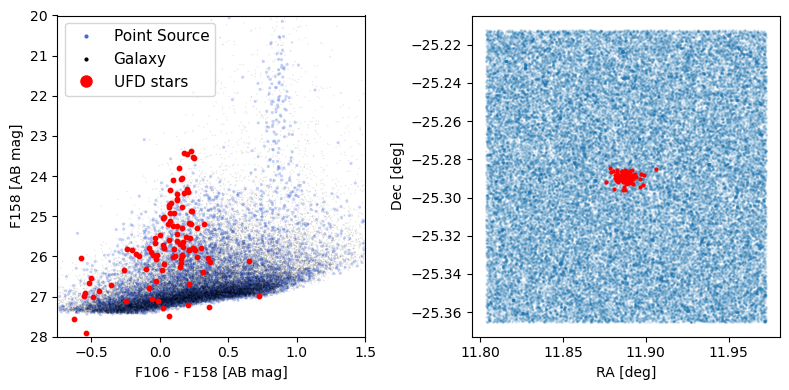

In [46]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(8, 4))
plt.sca(ax1)

qa_flag = full_cat['star_flag']
plt.scatter((full_cat['MAG_DERED_F106'] - full_cat['MAG_DERED_F158'])[qa_flag], 
            full_cat['MAG_DERED_F158'][qa_flag], s=5, alpha=0.3, color='royalblue', ec='none', label='Point Source')

qa_flag = full_cat['quality_flag'] & (~full_cat['star_flag'])
plt.scatter((full_cat['MAG_DERED_F106'] - full_cat['MAG_DERED_F158'])[qa_flag], 
            full_cat['MAG_DERED_F158'][qa_flag], color='k', ec='none', s=1, alpha=0.1, label='Galaxy')

flag = full_cat['MC_SOURCE_ID'] == 1 # UFD stars
plt.scatter(full_cat[flag]['MAG_DERED_F106'] - full_cat[flag]['MAG_DERED_F158'], 
            full_cat[flag]['MAG_DERED_F158'], s=10, ec='r', fc='r', label='UFD stars')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='royalblue', markeredgecolor='none',
           markersize=3, label='Point Source'),
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='k', markeredgecolor='none',
           markersize=3, label='Galaxy'),
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='r', markeredgecolor='r',
           markersize=8, label='UFD stars')
]
plt.legend(handles=legend_elements, frameon=True, fontsize=11)
plt.ylim(28, 20)
plt.xlim(-0.75, 1.5)
plt.xlabel('F106 - F158 [AB mag]')
plt.ylabel('F158 [AB mag]')

plt.sca(ax2)
plt.scatter(full_cat['RA'], full_cat['DEC'], s=1, alpha=0.1)
plt.scatter(full_cat[flag]['RA'], full_cat[flag]['DEC'], s=4, ec='r', fc='r')
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')

plt.tight_layout()